In [543]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import scipy
import time
from scipy.interpolate import lagrange

from ader_dg_transport.ader_dg_2D.base_ader_dg_2D import BaseADERDG2D
from ader_dg_transport.ader_dg_2D import elastic_wave_ader_standard
from ader_dg_transport.ader_dg_2D import elastic_wave_ader
import importlib

In [544]:
ny = 30
nx = 4 * ny

poly_order = 5
tend = 0.5

# L = 1.0
# mu = 1.0
rho = 1.0
# xlim = 2.0
xlim = 8.0
ylim = 2.0

In [545]:
cp = 2.2
gamma = 0.4593
cs = gamma * cp

mu = cs**2 * rho
L = (cp**2 * rho) - 2 * mu

## Standard

In [495]:
importlib.reload(elastic_wave_ader_standard)

# cfl = 0.5 * 0.5 / (2 * 5 + 1)
cfl = 0.9 * 0.5 / (2 * poly_order + 1)
dx = (xlim / nx)
dt = cfl * dx / (np.sqrt((L + 2 * mu) / rho))

solver = elastic_wave_ader_standard.ElasticWaveStandardAderDG2D(
    xlim, ylim, nx, ny, poly_order=poly_order, rho=rho, mu=mu, L=L, dt=dt, 
    y_periodic=False
)

xs = solver.xs[:, :, 0]
ys = solver.ys[:, :, 0]
# solver.oxy[:] = np.exp(-(xs - 5)**2 -(ys - 5)**2)
# solver.v[:] = np.exp(-(xs - 5)**2)

# print(dx / 3)

In [496]:
f0 = 10
sig = 0.05

def F(t):
    return (2 * np.pi * f0)**2 * ((4 * np.pi * (f0 * t - 1)**2) - 1) * np.exp(-2 * np.pi * (f0 * t - 1)**2)


def f(x, y, t):

    out = np.zeros((solver.nx, solver.ny, 5, solver.poly_order + 1, solver.poly_order + 1, solver.poly_order + 1))
    out[:, :, 0] = F(t) * np.exp(-((x - 0.5 * xlim)**2 + (y - (ylim - 0.2))**2) / (1 * sig**2))

    # out[:, :, 0] = F(t) * np.exp(-((x - 0.5 * xlim)**2 + (y - 0.5 * xlim)**2) / sig**2)
    return out

-0.5406936198479103


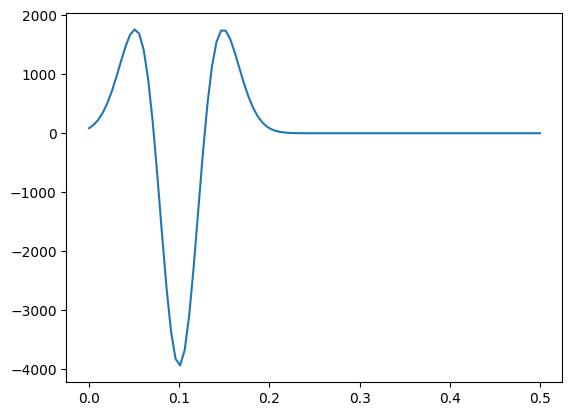

In [497]:
ts_ = np.linspace(0, 0.5, 100)
Fs = F(ts_)

print((np.diff(ts_)[0] * Fs).sum())

plt.plot(ts_, Fs)

In [498]:
%%time
E0 = solver.norm(*solver.get_vars(solver.state))

while solver.time < 1.0:
    solver.time_step(forcing_func=f)
    # solver.time_step()

E1 = solver.norm(*solver.get_vars(solver.state))

# print((E1 - E0) / E0)

CPU times: user 8min 33s, sys: 13min 33s, total: 22min 6s
Wall time: 2min 56s


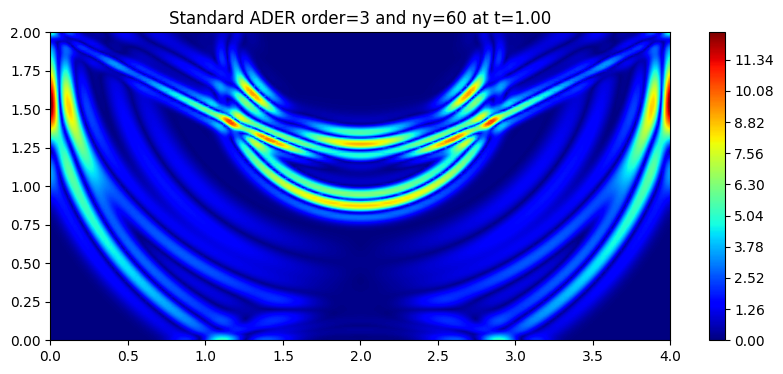

In [499]:
plt.figure(figsize=(10, 4))
plt.title(f'Standard ADER order={solver.poly_order} and ny={solver.ny} at t={solver.time:.2f}')
plt.tricontourf(xs.ravel(), ys.ravel(), np.sqrt(solver.u**2 + solver.v**2).ravel(), levels=1000, cmap='jet')
plt.colorbar()

0.0 0.0


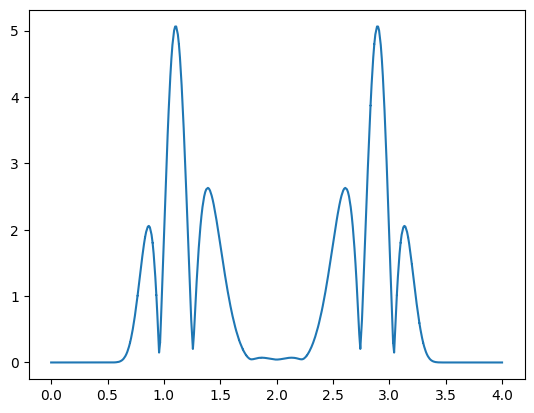

In [504]:
print(ys[:, 0, :, 0].min(), ys[:, 0, :, 0].max())
plt.plot(xs[:, 0, :, 0].ravel(), np.sqrt(solver.u**2 + solver.v**2)[:, 0, :, 0].ravel()) 

## New ADER

In [556]:
importlib.reload(elastic_wave_ader)

if poly_order == 3:
    cfl = 0.9 * 0.7
elif poly_order == 4:
    cfl = 0.9 * 0.44
elif poly_order == 5:
    cfl = 0.9 * 0.33
else:
    raise NotImplementedError

dx = (xlim / nx)
dt = cfl * dx / (np.sqrt((L + 2 * mu) / rho))
nsteps = int(0.5 / dt) + 1
dt = 0.5 / nsteps


solver = elastic_wave_ader.ElasticWaveAderDG2D(xlim, ylim, nx, ny, poly_order=poly_order, rho=rho, mu=mu, L=L, dt=dt, y_periodic=False)

xs = solver.xs[:, :, 0]
ys = solver.ys[:, :, 0]
# solver.oxy[:] = np.exp(-(xs - 5)**2 -(ys - 5)**2)
# solver.v[:] = np.exp(-(xs - 5)**2)

new_ader_times = [solver.time]
new_ader_states = [np.copy(solver.state)]

In [557]:
%%time
E0 = solver.norm(*solver.get_vars(solver.state))

while solver.time < 1.0:
    solver.time_step(forcing_func=f)

E1 = solver.norm(*solver.get_vars(solver.state))

new_ader_times.append(solver.time)
new_ader_states.append(np.copy(solver.state))
# print((E1 - E0) / E0)

CPU times: user 4min 23s, sys: 1min 25s, total: 5min 49s
Wall time: 47.2 s


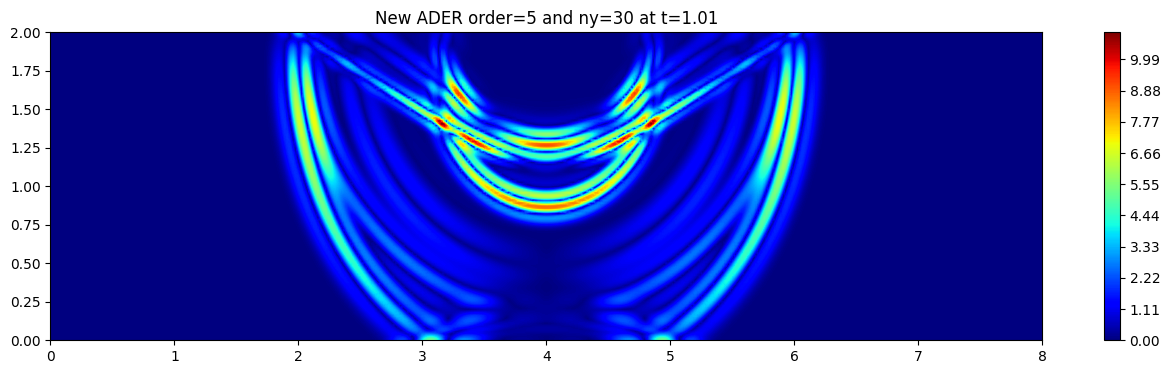

In [560]:
mask = abs(xs.ravel() - 4) < 20
idx = 1
u, v, oxx, oyy, oxy = solver.get_vars(new_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'New ADER order={solver.poly_order} and ny={solver.ny} at t={new_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [561]:
while solver.time < 2.0:
    solver.time_step(forcing_func=f)

new_ader_times.append(solver.time)
new_ader_states.append(np.copy(solver.state))

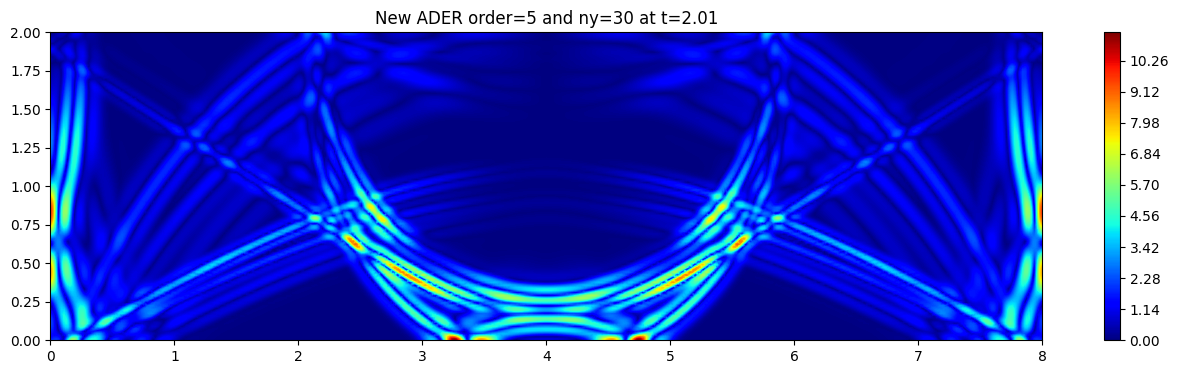

In [566]:
mask = abs(xs.ravel() - 4) < 20
idx = 2
u, v, oxx, oyy, oxy = solver.get_vars(new_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'New ADER order={solver.poly_order} and ny={solver.ny} at t={new_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()

In [564]:
while solver.time < 3.0:
    solver.time_step(forcing_func=f)

new_ader_times.append(solver.time)
new_ader_states.append(np.copy(solver.state))

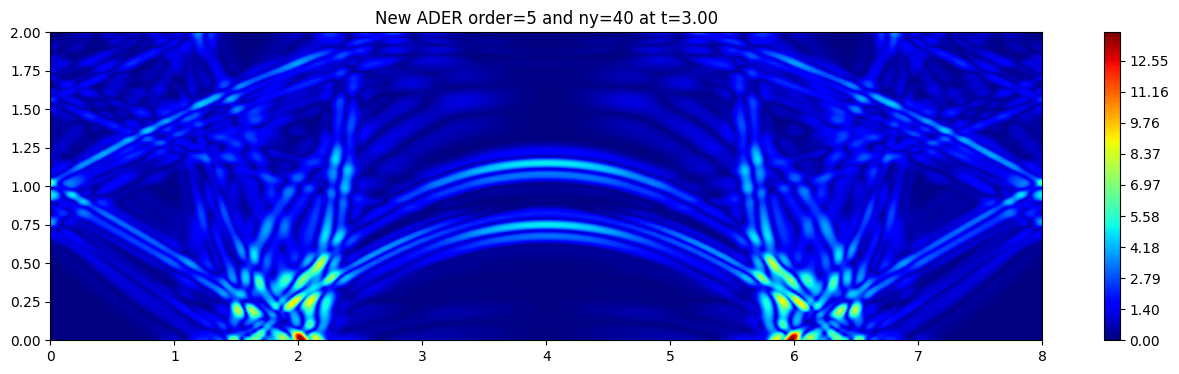

In [537]:
mask = abs(xs.ravel() - 4) < 20
idx = 3
u, v, oxx, oyy, oxy = solver.get_vars(new_ader_states[idx])

plt.figure(figsize=(16, 4))
plt.title(f'New ADER order={solver.poly_order} and ny={solver.ny} at t={new_ader_times[idx]:.2f}')
plt.tricontourf(xs.ravel()[mask], ys.ravel()[mask], np.sqrt(u**2 + v**2).ravel()[mask], levels=1000, cmap='jet')
plt.colorbar()